# Hafta 5: Dizi Analiz Araçları: k-mer, Motif, ORF, Restriksiyon Enzimleri ve Protein Özellikleri

**Biyoenformatiğe Giriş (Python & Biopython)**

**Bu haftanın hedefleri**
1. k-mer sayımı ve gözlenen/beklenen oranı ile dizi imzalarını incelemek.
2. IUPAC kodları ve `Bio.motifs` ile motif (PWM/PSSM) oluşturup dizide aramak.
3. Altı çerçevede açık okuma çerçevesi (ORF) bulan bir algoritma yazmak.
4. `Bio.Restriction` ile kesim yerlerini bulmak ve sanal jel elektroforezi çizmek.
5. `ProteinAnalysis` ile protein fizikokimyasal özelliklerini hesaplamak.

**Veri:** `ornek_plazmit.gb` (sentetik)

> **Kullanım:** Colab'da *Çalışma zamanı → Tümünü çalıştır* ile tüm hücreleri sırayla çalıştırabilirsiniz. Alıştırmaların çözümleri notebook'un sonundadır; önce kendiniz deneyin.

In [1]:
# Colab'da gerekli kütüphaneleri kur (yalnızca ilk çalıştırmada birkaç saniye sürer)
!pip -q install biopython 
import Bio
print('Biopython sürümü:', Bio.__version__)

Biopython sürümü: 1.88


In [2]:
# ---------------- VERİ SETİNİ HAZIRLA ----------------
# Veri dosyaları ders paketindeki 'veri' klasöründe de mevcuttur.
# İsterseniz Colab'ın sol panelinden 'veri' klasörü oluşturup dosyaları yükleyebilirsiniz;
# dosya bulunamazsa aşağıdaki fonksiyon(lar) AYNI veriyi (sabit tohum) yeniden üretir.
import os

def veri_uret_plazmit(klasor="veri"):
    """ornek_plazmit.gb (GenBank) ve ornek_genler.fasta dosyalarını üretir."""
    import os, random
    from Bio.Seq import Seq
    from Bio.SeqRecord import SeqRecord
    from Bio.SeqFeature import SeqFeature, FeatureLocation
    from Bio import SeqIO
    os.makedirs(klasor, exist_ok=True)
    rng = random.Random(42)
    stop = ["TAA", "TAG", "TGA"]
    anlamli = [a + b + c for a in "ACGT" for b in "ACGT" for c in "ACGT"
               if a + b + c not in stop]
    engel = ["GAATTC", "GGATCC", "AAGCTT"]          # EcoRI, BamHI, HindIII

    def rastgele(n, gc=0.5):
        w = [(1 - gc) / 2, gc / 2, gc / 2, (1 - gc) / 2]
        while True:
            s = "".join(rng.choices("ACGT", weights=w, k=n))
            if not any(e in s for e in engel):
                return s

    def orf(n_kodon, gc=0.5):
        while True:
            govde = "".join(rng.choice(anlamli) for _ in range(n_kodon - 2))
            s = "ATG" + govde + rng.choice(stop)
            if not any(e in s for e in engel):
                return s

    parcalar, ozellikler, pos = [], [], 0

    def ekle(s, tip=None, **q):
        nonlocal pos
        bas = pos
        parcalar.append(s)
        pos += len(s)
        if tip:
            ozellikler.append((tip, bas, pos, q))
        return bas, pos

    ekle(rastgele(180))
    ekle("TTGACA" + rastgele(17) + "TATAAT", "promoter", note="sigma70 benzeri promotor (-35/-10)")
    ekle(rastgele(12))
    ekle("AGGAGG", "RBS", note="Shine-Dalgarno dizisi")
    ekle(rastgele(7))
    cds1 = orf(300)
    ekle(cds1, "CDS+", gene="ornA", product="ornek protein A")
    ekle(rastgele(60))
    ekle("GAATTC", "misc_feature", note="EcoRI kesim yeri")
    ekle(rastgele(120))
    cds2 = orf(200, gc=0.45)
    ekle(str(Seq(cds2).reverse_complement()), "CDS-", gene="ornB", product="ornek protein B")
    ekle(rastgele(80))
    ekle("GGATCC", "misc_feature", note="BamHI kesim yeri")
    ekle(rastgele(150))
    ekle("AAGCTT", "misc_feature", note="HindIII kesim yeri")
    ekle(rastgele(3000 - pos - 20))
    ekle("GAATTC", "misc_feature", note="EcoRI kesim yeri (2)")
    ekle(rastgele(3000 - pos))
    dizi = "".join(parcalar)

    kayit = SeqRecord(Seq(dizi), id="pORNEK1", name="pORNEK1",
                      description="Sentetik ornek plazmit, Biyoenformatige Giris dersi")
    kayit.annotations["molecule_type"] = "DNA"
    kayit.annotations["topology"] = "circular"
    kayit.annotations["organism"] = "sentetik yapi"
    kayit.annotations["data_file_division"] = "SYN"
    kayit.annotations["date"] = "01-SEP-2026"
    kayit.features.append(SeqFeature(FeatureLocation(0, len(dizi), strand=1), type="source",
                                     qualifiers={"organism": ["sentetik yapi"], "mol_type": ["genomic DNA"]}))
    for tip, b, s, q in ozellikler:
        if tip.startswith("CDS"):
            strand = 1 if tip == "CDS+" else -1
            f = SeqFeature(FeatureLocation(b, s, strand=strand), type="CDS",
                           qualifiers={k: [v] for k, v in q.items()})
            f.qualifiers["translation"] = [str(f.extract(kayit.seq).translate(to_stop=True))]
            f.qualifiers["codon_start"] = ["1"]
            f.qualifiers["transl_table"] = ["11"]
        else:
            f = SeqFeature(FeatureLocation(b, s, strand=1), type=tip,
                           qualifiers={k: [v] for k, v in q.items()})
        kayit.features.append(f)
    SeqIO.write(kayit, os.path.join(klasor, "ornek_plazmit.gb"), "genbank")

    genler = [
        SeqRecord(Seq(cds1), id="ornA", description="plazmitteki ileri yonlu gen"),
        SeqRecord(Seq(cds2), id="ornB", description="plazmitteki ters yonlu gen (5'->3')"),
        SeqRecord(Seq(orf(150, gc=0.68)), id="yuksekGC", description="GC orani yuksek sentetik gen"),
        SeqRecord(Seq(orf(150, gc=0.32)), id="dusukGC", description="GC orani dusuk sentetik gen"),
        SeqRecord(Seq(orf(80)), id="kisaGen", description="kisa sentetik gen"),
    ]
    # GC eğilimli genleri kodon seçimiyle üret
    def gc_orf(n, gc):
        agirlik = []
        for k in anlamli:
            g = sum(c in "GC" for c in k)
            agirlik.append((gc / 0.5) ** g * ((1 - gc) / 0.5) ** (3 - g))
        while True:
            s = "ATG" + "".join(rng.choices(anlamli, weights=agirlik, k=n - 2)) + "TAA"
            if not any(e in s for e in engel):
                return s
    genler[2].seq = Seq(gc_orf(150, 0.68))
    genler[3].seq = Seq(gc_orf(150, 0.32))
    SeqIO.write(genler, os.path.join(klasor, "ornek_genler.fasta"), "fasta")


if not os.path.exists('veri/ornek_plazmit.gb'):
    veri_uret_plazmit()
print('veri klasörü:', sorted(os.listdir('veri')))


veri klasörü: ['1A8O.pdb', 'ornek_genler.fasta', 'ornek_plazmit.gb']


In [3]:
from Bio import SeqIO
from Bio.Seq import Seq
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter

plazmit = SeqIO.read("veri/ornek_plazmit.gb", "genbank")
dizi = plazmit.seq
print(plazmit.id, len(dizi), "bp")

pORNEK1 3000 bp


## 1. k-mer analizi
Bir dizideki uzunluğu *k* olan tüm alt dizgiler **k-mer**lerdir. Uzunluğu *N* olan dizide $N-k+1$ tane k-mer, olası farklı k-mer sayısı $4^k$.

| k | Olası k-mer | Kullanım örneği |
|---|---|---|
| 1 | 4 | Baz kompozisyonu |
| 2 | 16 | Dinükleotit (CpG) analizi |
| 3 | 64 | Kodon kullanımı |
| 6–8 | 4 096–65 536 | Motif, restriksiyon yeri |
| 21–31 | çok büyük | Genom birleştirme (de Bruijn grafı) |

**CpG gözlenen/beklenen oranı:** $\dfrac{n_{CG}\cdot N}{n_C \cdot n_G}$ — omurgalı genomlarında CpG dinükleotidi azdır (≈ 0.2–0.25), CpG adalarında ≈ 1.

In [4]:
def kmer_say(dizi, k):
    dizi = str(dizi)
    return Counter(dizi[i:i + k] for i in range(len(dizi) - k + 1))

for k in [1, 2, 3]:
    c = kmer_say(dizi, k)
    print(f"k={k}: farklı k-mer={len(c)} / {4**k}, en sık 5:", c.most_common(5))

k=1: farklı k-mer=4 / 4, en sık 5: [('C', 785), ('G', 755), ('T', 735), ('A', 725)]
k=2: farklı k-mer=16 / 16, en sık 5: [('CC', 216), ('CA', 204), ('GG', 202), ('GC', 202), ('AT', 199)]
k=3: farklı k-mer=64 / 64, en sık 5: [('ACC', 66), ('CGT', 62), ('CCC', 61), ('CCA', 59), ('ATT', 59)]


Plazmit CpG o/e = 1.01


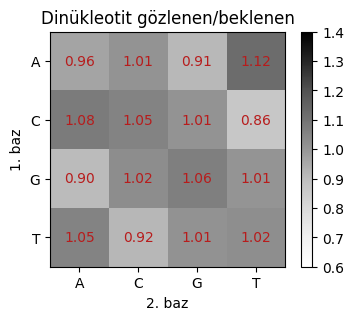

In [5]:
def cpg_oe(d):
    d = str(d)
    return d.count("CG") * len(d) / (d.count("C") * d.count("G"))

print(f"Plazmit CpG o/e = {cpg_oe(dizi):.2f}")

# Dinükleotit o/e ısı haritası
c1, c2 = kmer_say(dizi, 1), kmer_say(dizi, 2)
N = len(dizi)
oe = np.array([[c2[a + b] * N / (c1[a] * c1[b]) for b in "ACGT"] for a in "ACGT"])   # n_ab * N / (n_a * n_b)
plt.figure(figsize=(3.8, 3.2))
plt.imshow(oe, cmap="Greys", vmin=0.6, vmax=1.4)
plt.xticks(range(4), list("ACGT")); plt.yticks(range(4), list("ACGT"))
for i in range(4):
    for j in range(4):
        plt.text(j, i, f"{oe[i,j]:.2f}", ha="center", va="center", color="#b71c1c")
plt.xlabel("2. baz"); plt.ylabel("1. baz"); plt.title("Dinükleotit gözlenen/beklenen"); plt.colorbar(); plt.tight_layout(); plt.show()

## 2. Motif arama

### 2.1 IUPAC belirsizlik kodları
| Kod | Anlam | Kod | Anlam |
|---|---|---|---|
| R | A/G (pürin) | Y | C/T (pirimidin) |
| S | G/C | W | A/T |
| K | G/T | M | A/C |
| N | herhangi | B, D, H, V | 3'lü kombinasyonlar |

Örneğin σ⁷⁰ promotörünün −10 bölgesi yaklaşık `TATAAT`, esnek hali `TATRNT` gibi yazılabilir.

In [6]:
from Bio.SeqUtils import nt_search

sonuc = nt_search(str(dizi), "TATRNT")
print("Arama deseni (regex):", sonuc[0])
konumlar = sonuc[1:]            # ilk eleman desen, kalanlar konumlar
print("Bulunan konumlar (0 tabanlı):", konumlar[:15], "..." if len(konumlar) > 15 else "")
print("Toplam:", len(konumlar))
print("Beklenen (rastgele):", round(len(dizi) * (1/4)**4 * (2/4) * 1, 1), "(tek iplik)")

Arama deseni (regex): TAT[AG][GATC]T
Bulunan konumlar (0 tabanlı): [203, 233, 812, 2048, 2347, 2733] 
Toplam: 6
Beklenen (rastgele): 5.9 (tek iplik)


### 2.2 Pozisyon ağırlık matrisi (PWM) ve PSSM
Hizalanmış motif örneklerinden:
1. **Sayım matrisi** $n_{b,i}$ (i. konumda b bazı kaç kez)
2. **Olasılık (PWM)**: $p_{b,i} = \dfrac{n_{b,i} + \alpha}{N + 4\alpha}$ (α: sahte sayım / pseudocount)
3. **Log-odds (PSSM)**: $s_{b,i} = \log_2 \dfrac{p_{b,i}}{q_b}$ (q_b: arka plan olasılığı, genelde 0.25)
4. Bir dizinin skoru = konumlardaki skorların **toplamı**.

**Elle örnek:** Motif örnekleri `TATAAT`, `TATAAT`, `TACAAT`, `GATAAT` (N=4), α=0.5 (her baz için), q=0.25.

| Konum | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|
| Sayım | T:3, G:1 | A:4 | T:3, C:1 | A:4 | A:4 | T:4 |

1. konumda T: $p = (3+0.5)/(4+2) = 0.583$, $s = \log_2(0.583/0.25) = 1.22$ bit;
A: $p = 0.5/6 = 0.083$, $s = \log_2(0.333) = -1.58$ bit.
4 sayımlı konumda: $p = 4.5/6 = 0.75$, $s = \log_2 3 = 1.585$ bit.
**`TATAAT` skoru** = 1.22 + 1.585 + 1.22 + 1.585 + 1.585 + 1.585 = **8.78 bit**.

In [7]:
from Bio import motifs

ornekler = [Seq(s) for s in ["TATAAT", "TATAAT", "TACAAT", "GATAAT"]]
m = motifs.create(ornekler)
print("Sayım matrisi:\n", m.counts)
pwm = m.counts.normalize(pseudocounts=0.5)
pssm = pwm.log_odds()          # arka plan varsayılanı: eşit (0.25)
print("PSSM:\n", pssm)
print("Konsensüs:", m.consensus, "| TATAAT skoru:", round(float(pssm.calculate(Seq("TATAAT"))), 2), "bit")
print("Maksimum skor:", round(pssm.max, 2), "| minimum skor:", round(pssm.min, 2))

Sayım matrisi:
         0      1      2      3      4      5
A:   0.00   4.00   0.00   4.00   4.00   0.00
C:   0.00   0.00   1.00   0.00   0.00   0.00
G:   1.00   0.00   0.00   0.00   0.00   0.00
T:   3.00   0.00   3.00   0.00   0.00   4.00

PSSM:
         0      1      2      3      4      5
A:  -1.58   1.58  -1.58   1.58   1.58  -1.58
C:  -1.58  -1.58   0.00  -1.58  -1.58  -1.58
G:   0.00  -1.58  -1.58  -1.58  -1.58  -1.58
T:   1.22  -1.58   1.22  -1.58  -1.58   1.58

Konsensüs: TATAAT | TATAAT skoru: 8.78 bit
Maksimum skor: 8.78 | minimum skor: -9.51


Eşik 6.0 bit üstü isabetler (negatif konum = ters iplik):
  konum   203 (+)  skor=8.78  dizi=TATAAT
  konum   280 (+)  skor=7.56  dizi=TACAAT
  konum   470 (-)  skor=7.56  dizi=GATAAT
  konum   678 (-)  skor=7.56  dizi=TACAAT
  konum   812 (+)  skor=8.78  dizi=TATAAT
  konum  1175 (-)  skor=7.56  dizi=TACAAT
  konum  1860 (-)  skor=7.56  dizi=GATAAT
  konum  2692 (-)  skor=8.78  dizi=TATAAT


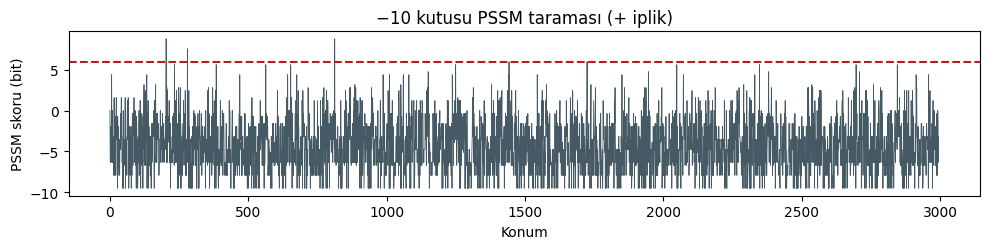

In [8]:
# Plazmit boyunca PSSM taraması (her iki iplik)
esik = 6.0
bulunan = [(konum, round(float(skor), 2)) for konum, skor in pssm.search(dizi, threshold=esik)]
print(f"Eşik {esik} bit üstü isabetler (negatif konum = ters iplik):")
for k, s in bulunan:
    iplik = "+" if k >= 0 else "-"
    gercek = k if k >= 0 else len(dizi) + k
    print(f"  konum {gercek:5d} ({iplik})  skor={s}  dizi={dizi[gercek:gercek+6] if k>=0 else dizi[gercek:gercek+6].reverse_complement()}")

# Tüm konumların skor dağılımı
skorlar = pssm.calculate(dizi)
plt.figure(figsize=(10, 2.6))
plt.plot(skorlar, lw=0.6, color="#455a64"); plt.axhline(esik, color="#b71c1c", ls="--")
plt.xlabel("Konum"); plt.ylabel("PSSM skoru (bit)"); plt.title("−10 kutusu PSSM taraması (+ iplik)"); plt.tight_layout(); plt.show()

## 3. Açık okuma çerçevesi (ORF) bulma
**ORF:** bir başlangıç kodonuyla (ATG) başlayıp aynı çerçevedeki ilk dur kodonunda biten, en az *L* kodonluk bölge.

Algoritma (her 6 çerçeve için):
1. Diziyi kodonlara böl.
2. ATG görünce "açık" durumuna geç, konumu kaydet.
3. Dur kodonu görünce ORF'u kapat; uzunluk ≥ eşikse kaydet.

In [9]:
DUR = {"TAA", "TAG", "TGA"}

def orf_bul(dizi, min_kodon=100):
    dizi = str(dizi).upper()
    N = len(dizi)
    rc = str(Seq(dizi).reverse_complement())
    orfs = []
    for iplik, d in [(1, dizi), (-1, rc)]:
        for cerceve in range(3):
            bas = None
            for i in range(cerceve, N - 2, 3):
                kodon = d[i:i + 3]
                if bas is None and kodon == "ATG":
                    bas = i
                elif bas is not None and kodon in DUR:
                    if (i + 3 - bas) // 3 >= min_kodon:
                        if iplik == 1:
                            orfs.append((bas, i + 3, 1, cerceve + 1))
                        else:            # ters iplik koordinatlarını ileri ipliğe çevir
                            orfs.append((N - (i + 3), N - bas, -1, -(cerceve + 1)))
                    bas = None
    return sorted(orfs)

orfs = orf_bul(dizi, min_kodon=100)
tablo = pd.DataFrame(orfs, columns=["bas", "bitis", "iplik", "cerceve"])
tablo["uzunluk_bp"] = tablo.bitis - tablo.bas
tablo["protein_aa"] = tablo.uzunluk_bp // 3 - 1
tablo

,bas,bitis,iplik,cerceve,uzunluk_bp,protein_aa
0,234,1134,1,1,900,299
1,1320,1935,-1,-1,615,204
2,1590,1947,1,1,357,118


In [10]:
print("GenBank açıklamasındaki CDS'ler:")
for f in plazmit.features:
    if f.type == "CDS":
        print(f"  {f.qualifiers['gene'][0]}: {int(f.location.start)}-{int(f.location.end)} iplik {f.location.strand}")

# ORF uzunluğu eşiğinin etkisi
for L in [30, 50, 100, 150]:
    print(f"min {L:3d} kodon -> {len(orf_bul(dizi, L))} ORF")

GenBank açıklamasındaki CDS'ler:
  ornA: 234-1134 iplik 1
  ornB: 1320-1920 iplik -1
min  30 kodon -> 19 ORF
min  50 kodon -> 10 ORF
min 100 kodon -> 3 ORF
min 150 kodon -> 2 ORF


> **Gözlem:** Algoritma iki CDS'i de buldu; ancak `ornB` için bulunan ORF açıklamadakinden biraz uzun: aynı çerçevede daha yukarıda
bir ATG daha var ve algoritmamız **ilk (en uzun)** ATG'yi seçiyor. Ayrıca `ornB` bölgesiyle örtüşen, ileri iplikte üçüncü bir ORF
çıktı — bu büyük olasılıkla *sahte* bir ORF'tur. Gerçek gen bulucular (Prodigal, GeneMark) RBS, kodon kullanımı gibi ek sinyalleri
istatistiksel olarak birleştirir; bu, ileride göreceğimiz makine öğrenmesi yaklaşımlarının motivasyonudur.

> **Tartışma:** Rastgele dizide dur kodonu olasılığı 3/64 olduğundan, uzunluğu ≥ *L* kodon olan bir ORF'un rastgele oluşma olasılığı yaklaşık $(61/64)^L$'dir.
L = 100 için ≈ 0.0082. Kısa eşikler çok sayıda yanlış pozitif üretir.

## 4. Restriksiyon enzimleri
| Enzim | Tanıma dizisi | Kesim | Uç tipi |
|---|---|---|---|
| EcoRI | G^AATTC | 1. bazdan sonra | 5' yapışkan uç |
| BamHI | G^GATCC | 1. bazdan sonra | 5' yapışkan uç |
| HindIII | A^AGCTT | 1. bazdan sonra | 5' yapışkan uç |
| SmaI | CCC^GGG | ortadan | Küt uç |

In [11]:
from Bio.Restriction import EcoRI, BamHI, HindIII, SmaI, RestrictionBatch, Analysis

for enz in [EcoRI, BamHI, HindIII, SmaI]:
    kesim = enz.search(dizi, linear=False)          # plazmit dairesel!
    print(f"{str(enz):8s} {enz.site:8s} kesim konumları (1 tabanlı): {kesim}")

analiz = Analysis(RestrictionBatch([EcoRI, BamHI, HindIII, SmaI]), dizi, linear=False)
analiz.print_that()

EcoRI    GAATTC   kesim konumları (1 tabanlı): [1196, 2982]
BamHI    GGATCC   kesim konumları (1 tabanlı): [2002]
HindIII  AAGCTT   kesim konumları (1 tabanlı): [2158]
SmaI     CCCGGG   kesim konumları (1 tabanlı): [1849]
BamHI      :  2002.
EcoRI      :  1196, 2982.
HindIII    :  2158.
SmaI       :  1849.



### Sayısal örnek — Dairesel DNA'da parça boyları
Dairesel bir molekülde *n* kesim → *n* parça (doğrusal DNA'da *n+1*).
Kesim konumları $c_1<c_2<\dots<c_n$ ise parça boyları $c_2-c_1, \dots, c_n-c_{n-1}$ ve $(L - c_n) + c_1$ (sarmal parça).

In [12]:
def dairesel_parcalar(kesimler, L):
    k = sorted(kesimler)
    if not k:
        return [L]
    return [k[i + 1] - k[i] for i in range(len(k) - 1)] + [L - k[-1] + k[0]]

L = len(dizi)
sindirimler = {
    "EcoRI": EcoRI.search(dizi, linear=False),
    "BamHI": BamHI.search(dizi, linear=False),
    "EcoRI+HindIII": EcoRI.search(dizi, linear=False) + HindIII.search(dizi, linear=False),
    "EcoRI+BamHI+HindIII": EcoRI.search(dizi, linear=False) + BamHI.search(dizi, linear=False) + HindIII.search(dizi, linear=False),
}
for ad, k in sindirimler.items():
    print(f"{ad:22s} kesimler={sorted(k)}  parçalar={dairesel_parcalar(k, L)}")

EcoRI                  kesimler=[1196, 2982]  parçalar=[1786, 1214]
BamHI                  kesimler=[2002]  parçalar=[3000]
EcoRI+HindIII          kesimler=[1196, 2158, 2982]  parçalar=[962, 824, 1214]
EcoRI+BamHI+HindIII    kesimler=[1196, 2002, 2158, 2982]  parçalar=[806, 156, 824, 1214]


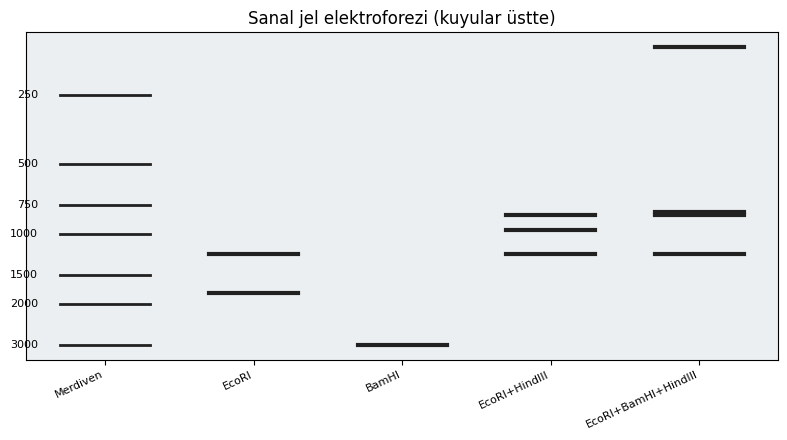

In [13]:
# Sanal agaroz jel: göç mesafesi ~ -log10(boy)
merdiven = [3000, 2000, 1500, 1000, 750, 500, 250]
seritler = {"Merdiven": merdiven, **{ad: dairesel_parcalar(k, L) for ad, k in sindirimler.items()}}
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (ad, parcalar) in enumerate(seritler.items()):
    for p in parcalar:
        y = -np.log10(p)
        ax.plot([i - 0.3, i + 0.3], [y, y], color="#212121", lw=3 if ad != "Merdiven" else 2)
        if ad == "Merdiven":
            ax.text(i - 0.45, y, str(p), ha="right", va="center", fontsize=8)
ax.set_xticks(range(len(seritler))); ax.set_xticklabels(seritler.keys(), rotation=25, ha="right", fontsize=8)
ax.set_yticks([]); ax.set_facecolor("#eceff1"); ax.set_title("Sanal jel elektroforezi (kuyular üstte)")
plt.tight_layout(); plt.show()

## 5. Protein fizikokimyasal özellikleri — `ProteinAnalysis`

| Özellik | Anlamı |
|---|---|
| Molekül ağırlığı | Da cinsinden kütle |
| İzoelektrik nokta (pI) | Net yükün sıfır olduğu pH |
| GRAVY | Ortalama hidropati (Kyte–Doolittle); > 0 hidrofobik |
| Aromatiklik | F + W + Y oranı |
| Kararsızlık indeksi | > 40 ise in vitro kararsız kabul edilir |

In [14]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

satirlar = []
for f in plazmit.features:
    if f.type == "CDS":
        prot = str(f.extract(dizi).translate(table=11, to_stop=True))
        pa = ProteinAnalysis(prot)
        satirlar.append({"gen": f.qualifiers["gene"][0], "uzunluk": len(prot),
                         "MW (kDa)": round(pa.molecular_weight() / 1000, 2),
                         "pI": round(pa.isoelectric_point(), 2), "GRAVY": round(pa.gravy(), 3),
                         "aromatiklik": round(pa.aromaticity(), 3),
                         "kararsızlık": round(pa.instability_index(), 1)})
# Karşılaştırma için kısa bir peptit
pa = ProteinAnalysis("GIGKFLHSAKKFGKAFVGEIMNS")          # magainin-2 (antimikrobiyal peptit)
satirlar.append({"gen": "magainin-2", "uzunluk": 23, "MW (kDa)": round(pa.molecular_weight()/1000, 2),
                 "pI": round(pa.isoelectric_point(), 2), "GRAVY": round(pa.gravy(), 3),
                 "aromatiklik": round(pa.aromaticity(), 3), "kararsızlık": round(pa.instability_index(), 1)})
pd.DataFrame(satirlar)

,gen,uzunluk,MW (kDa),pI,GRAVY,aromatiklik,kararsızlık
0,ornA,299,33.19,9.43,0.064,0.090,31.6
1,ornB,199,22.48,10.24,-0.695,0.101,55.4
2,magainin-2,23,2.47,10.00,0.083,0.130,-0.1


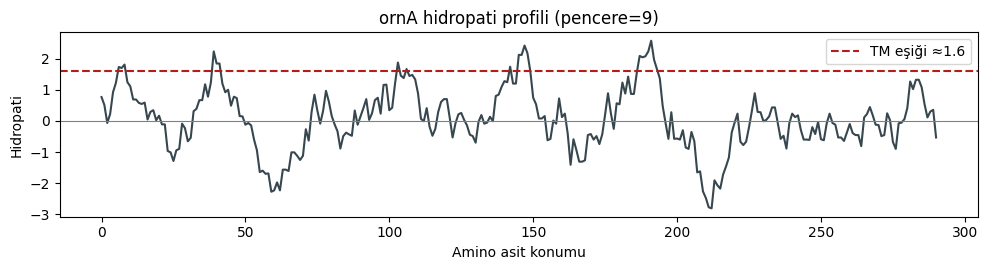

In [15]:
# Kyte-Doolittle hidropati profili (kayan pencere)
from Bio.SeqUtils.ProtParamData import kd
prot = str([f for f in plazmit.features if f.type == "CDS"][0].extract(dizi).translate(table=11, to_stop=True))
pa = ProteinAnalysis(prot)
profil = pa.protein_scale(kd, window=9)
plt.figure(figsize=(10, 2.8))
plt.plot(profil, color="#37474f"); plt.axhline(0, color="gray", lw=0.8); plt.axhline(1.6, color="#b71c1c", ls="--", label="TM eşiği ≈1.6")
plt.xlabel("Amino asit konumu"); plt.ylabel("Hidropati"); plt.title("ornA hidropati profili (pencere=9)"); plt.legend(); plt.tight_layout(); plt.show()

## 6. GC eğimi (GC skew) — replikasyon orijini ipucu
$\text{skew} = \dfrac{G - C}{G + C}$; bakteri genomlarında kümülatif eğrinin minimumu genelde replikasyon orijinine yakındır.

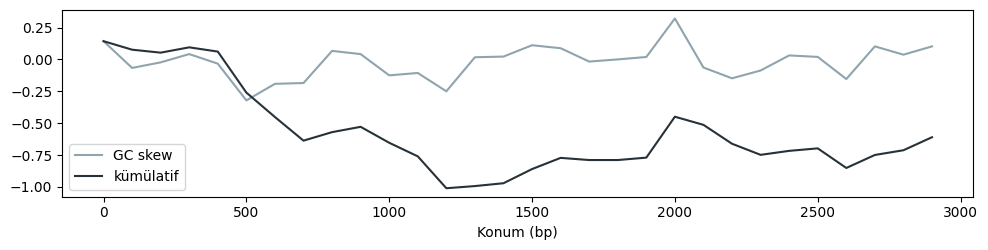

In [16]:
from Bio.SeqUtils import GC_skew
skew = GC_skew(dizi, window=100)
plt.figure(figsize=(10, 2.6))
plt.plot(np.arange(len(skew)) * 100, skew, label="GC skew", color="#90a4ae")
plt.plot(np.arange(len(skew)) * 100, np.cumsum(skew), label="kümülatif", color="#263238")
plt.xlabel("Konum (bp)"); plt.legend(); plt.tight_layout(); plt.show()

## 7. Alıştırmalar
1. Plazmitteki tüm 4-merleri sayın; 256 olası 4-merden hangileri hiç görülmüyor? Rastgele 3000 bp'lik dizide kaç tanesinin hiç görülmemesini beklersiniz? *(İpucu: $256\cdot(1-1/256)^{2997}$)*
2. `-35` kutusu için `TTGACA`, `TTGACT`, `TTGATA`, `CTGACA` örneklerinden bir PSSM oluşturun (pseudocount 0.5) ve plazmitte en yüksek skorlu konumu bulun.
3. `orf_bul` fonksiyonunu ATG yanında GTG ve TTG başlangıç kodonlarını da kabul edecek şekilde genişletin. ORF sayısı nasıl değişti?
4. Plazmiti SmaI + EcoRI ile kestiğinizde oluşan parçaları hesaplayın.
5. `ornB` proteininin pI değerini hesaplayın. pH 7.4'te net yükü pozitif mi negatif mi? (`pa.charge_at_pH(7.4)`)

---
## Çözümler

In [17]:
import itertools
# 1
c4 = kmer_say(dizi, 4)
yok = [''.join(p) for p in itertools.product("ACGT", repeat=4) if ''.join(p) not in c4]
print(f"1) Görülmeyen 4-mer: {len(yok)} {yok[:8]} | beklenen ≈ {256*(1-1/256)**(len(dizi)-3):.1f}")
# 2
m35 = motifs.create([Seq(s) for s in ["TTGACA", "TTGACT", "TTGATA", "CTGACA"]])
p35 = m35.counts.normalize(pseudocounts=0.5).log_odds()
sk = p35.calculate(dizi)
print(f"2) en yüksek skor {max(sk):.2f} bit, konum {int(np.argmax(sk))}: {dizi[int(np.argmax(sk)):int(np.argmax(sk))+6]}")
# 3
def orf_bul2(dizi, min_kodon=100, baslangic=("ATG", "GTG", "TTG")):
    dizi = str(dizi); N = len(dizi); rc = str(Seq(dizi).reverse_complement()); out = []
    for iplik, d in [(1, dizi), (-1, rc)]:
        for fr in range(3):
            bas = None
            for i in range(fr, N - 2, 3):
                k = d[i:i+3]
                if bas is None and k in baslangic:
                    bas = i
                elif bas is not None and k in DUR:
                    if (i + 3 - bas) // 3 >= min_kodon:
                        out.append((bas, i + 3, iplik))
                    bas = None
    return out
print("3) ATG:", len(orf_bul(dizi, 100)), "| ATG/GTG/TTG:", len(orf_bul2(dizi, 100)))
# 4
k = SmaI.search(dizi, linear=False) + EcoRI.search(dizi, linear=False)
print("4) SmaI+EcoRI kesimler:", sorted(k), "parçalar:", dairesel_parcalar(k, L))
# 5
ornB = [f for f in plazmit.features if f.qualifiers.get("gene") == ["ornB"]][0]
pa = ProteinAnalysis(str(ornB.extract(dizi).translate(table=11, to_stop=True)))
print(f"5) pI={pa.isoelectric_point():.2f}, pH 7.4 yükü={pa.charge_at_pH(7.4):.2f}")

1) Görülmeyen 4-mer: 0 [] | beklenen ≈ 0.0
2) en yüksek skor 8.42 bit, konum 180: TTGACA
3) ATG: 3 | ATG/GTG/TTG: 4
4) SmaI+EcoRI kesimler: [1196, 1849, 2982] parçalar: [653, 1133, 1214]
5) pI=10.24, pH 7.4 yükü=13.53
